In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import os

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
# Load dataset
file_path = '/content/gdrive/My Drive/Cardiovascular_Disease_Dataset.csv'
df = pd.read_csv(file_path)
print(df.head())

   patientid  age  gender  chestpain  restingBP  serumcholestrol  \
0     103368   53       1          2        171                0   
1     119250   40       1          0         94              229   
2     119372   49       1          2        133              142   
3     132514   43       1          0        138              295   
4     146211   31       1          1        199                0   

   fastingbloodsugar  restingrelectro  maxheartrate  exerciseangia  oldpeak  \
0                  0                1           147              0      5.3   
1                  0                1           115              0      3.7   
2                  0                0           202              1      5.0   
3                  1                1           153              0      3.2   
4                  0                2           136              0      5.3   

   slope  noofmajorvessels  target  
0      3                 3       1  
1      1                 1       0  
2    

In [4]:
# Check for missing values
df = df.dropna()

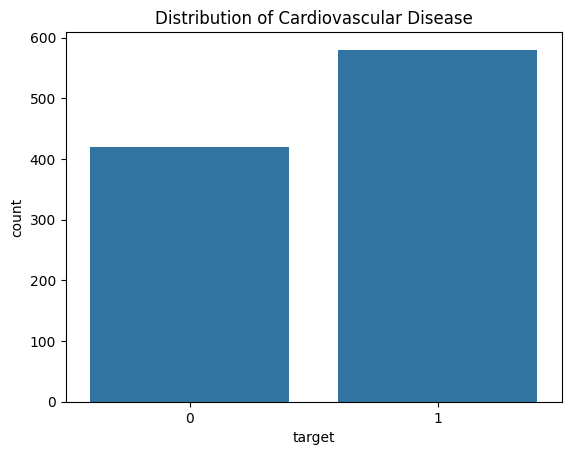

In [5]:
# Visualizing target distribution
sns.countplot(x='target', data=df)
plt.title('Distribution of Cardiovascular Disease')
plt.show()

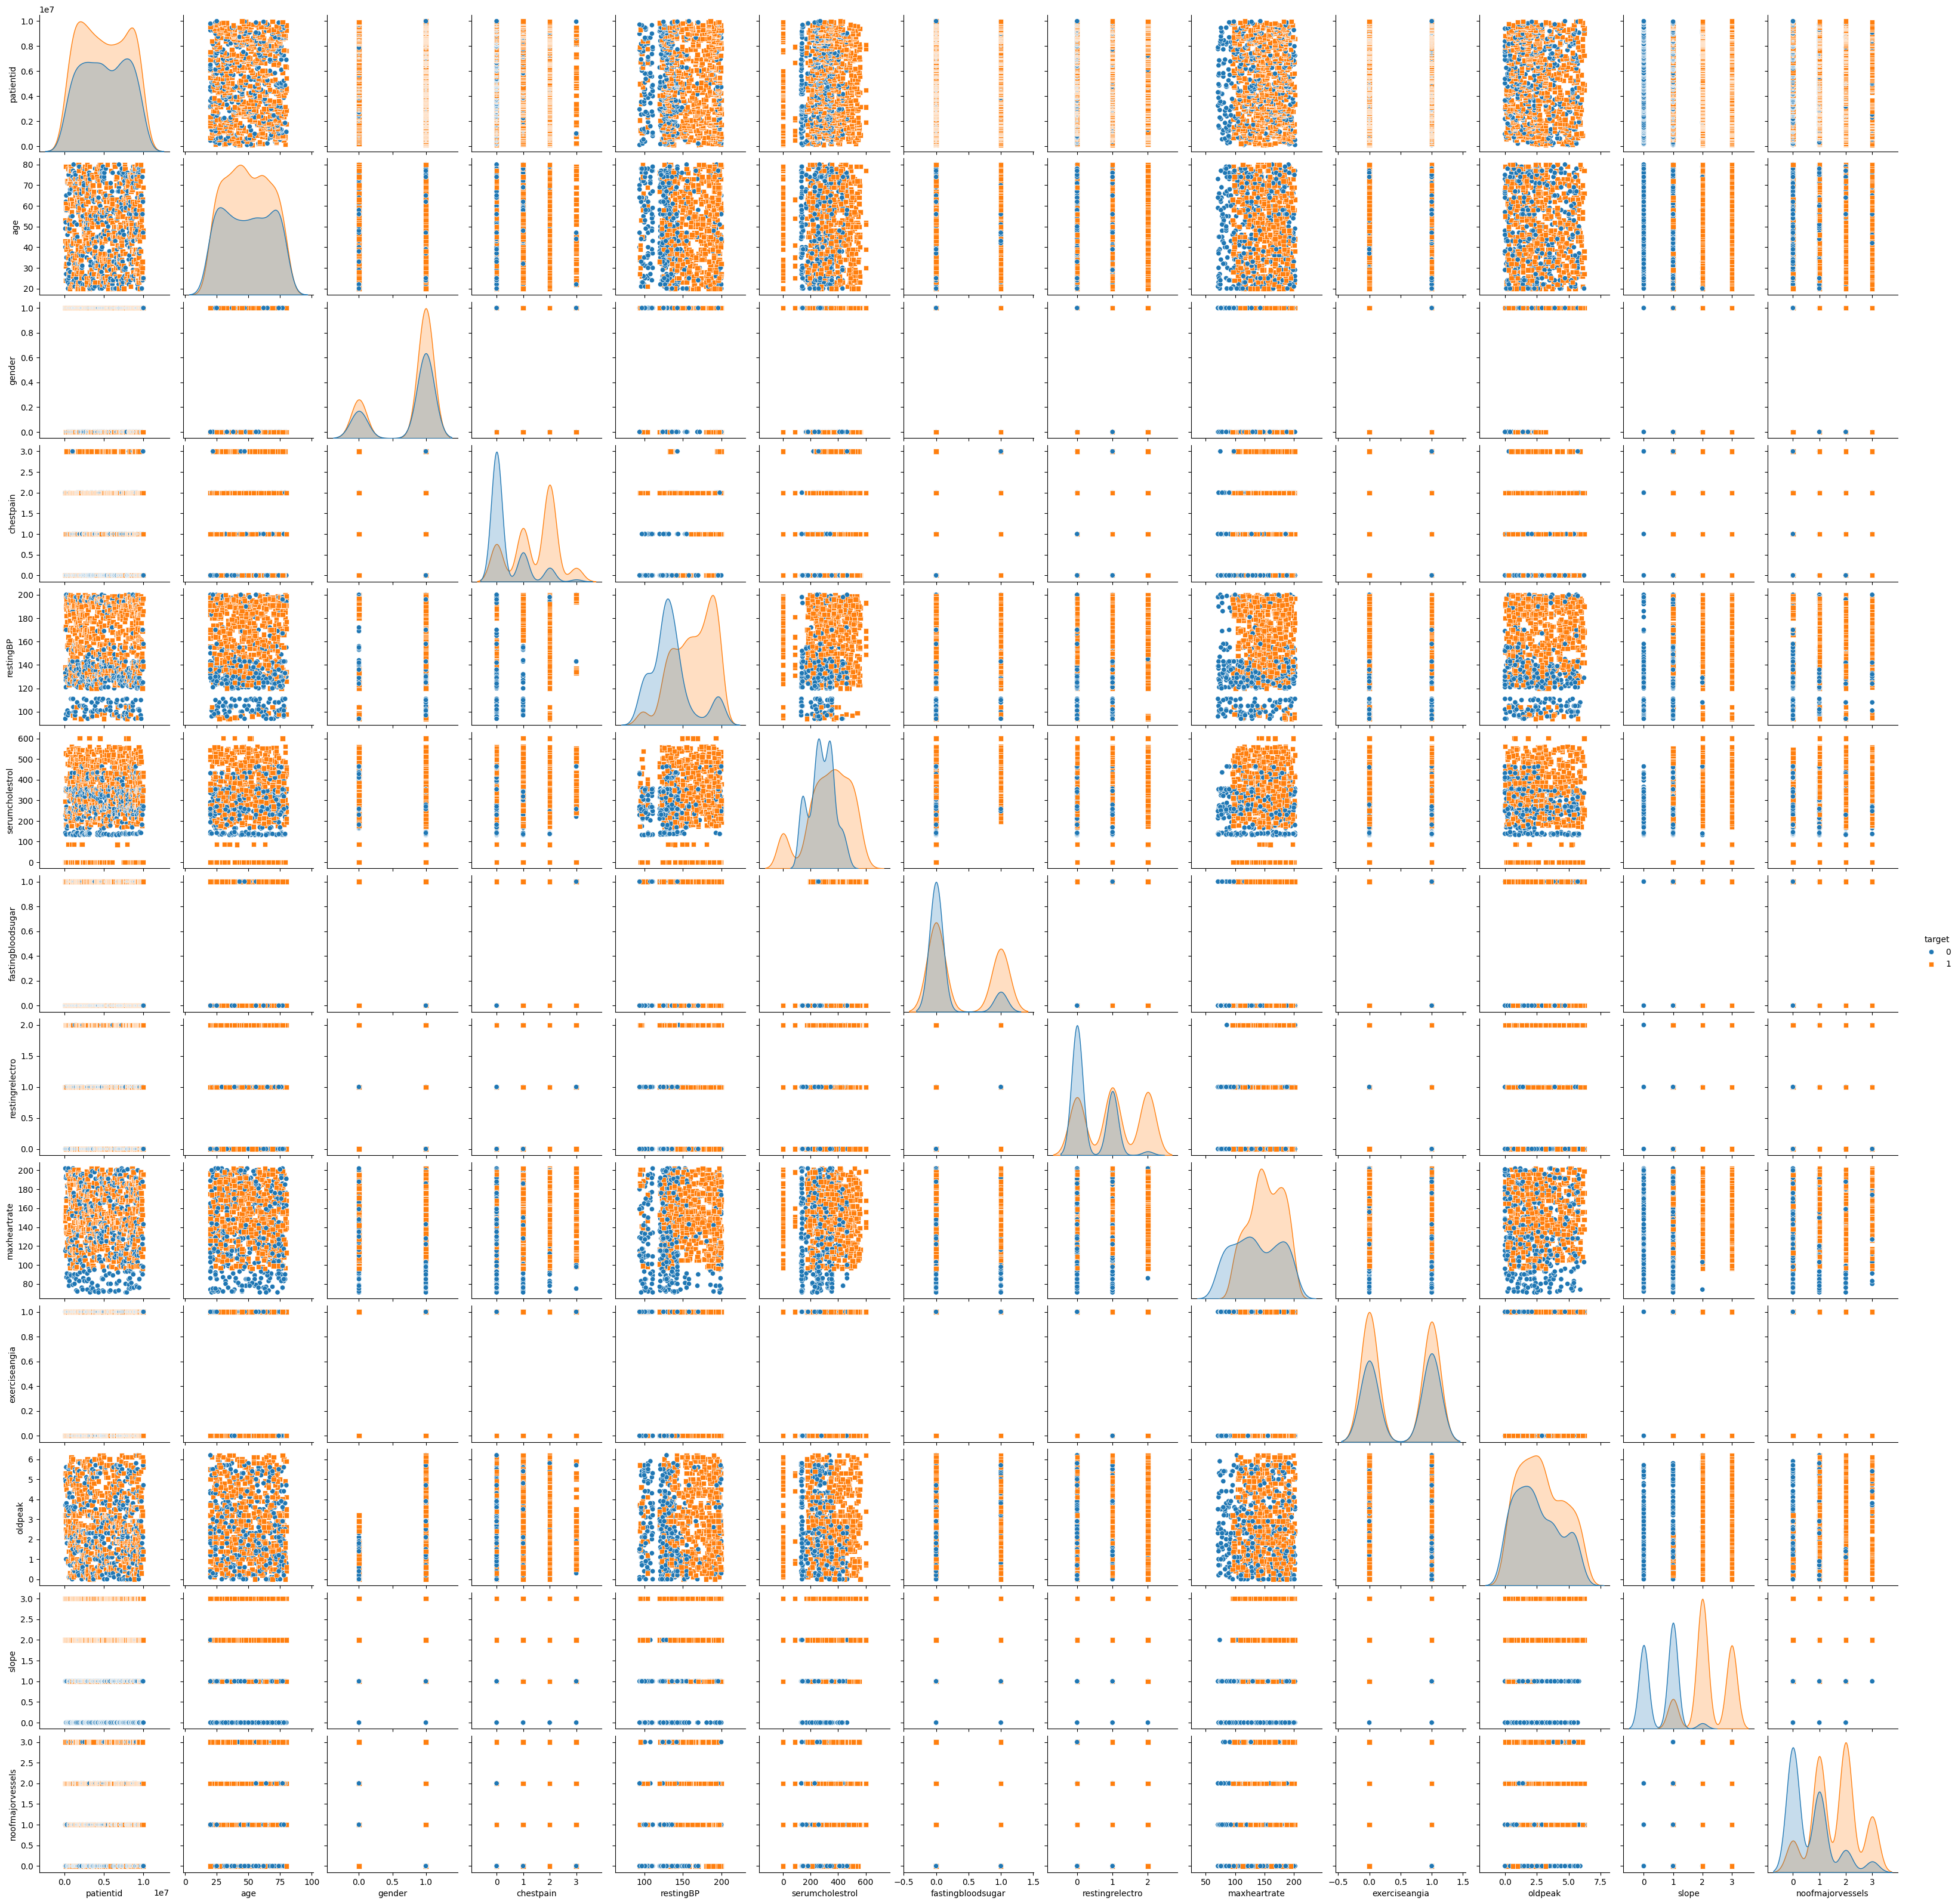

In [6]:
# Pairplot for selected features along with target variable
sns.pairplot(df, hue="target", diag_kind="kde", markers=["o", "s"])
plt.show()

In [7]:
# Dropping unimportant columns
df = df.drop(columns=['patientid'])

# Separating features and target variable
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# Training using Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=10)
rf_model.fit(X_train_scaled, y_train)

y_pred = rf_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Random Forest Model Accuracy: {accuracy:.2f}')
print(report)

Random Forest Model Accuracy: 0.96
              precision    recall  f1-score   support

           0       0.95      0.96      0.96        84
           1       0.97      0.97      0.97       116

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.97      0.96      0.97       200



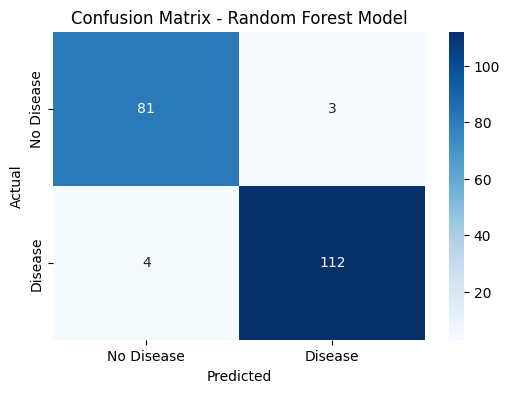

In [9]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest Model')
plt.show()

In [10]:
# Hyperparameter tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=10)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=10), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [11]:
# Best parameters
print("Best Parameters:", grid_search.best_params_)

best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test_scaled)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f'Tuned Model Accuracy: {accuracy_best:.2f}')

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Tuned Model Accuracy: 0.96


In [12]:
# Save model
joblib.dump(best_rf, 'rf_CVD.pkl')

['rf_CVD.pkl']